In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [54]:
df = pd.read_csv("Student_Performance.csv")
df.sample(20)    #picks random 5 from datasets

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
2195,8,71,Yes,9,1,63.0
4478,6,59,Yes,8,5,49.0
1290,8,73,No,4,9,68.0
237,2,92,No,7,7,70.0
3185,9,66,Yes,4,7,62.0
8358,2,73,No,4,0,50.0
417,9,73,Yes,9,4,72.0
1601,5,99,No,7,5,89.0
2359,6,79,Yes,7,9,70.0
4487,8,71,No,9,0,66.0


In [55]:
df.describe(include='all')

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2,NaN,NaN,NaN
top,NaN,NaN,No,NaN,NaN,NaN
freq,NaN,NaN,5052,NaN,NaN,NaN
mean,4.992900,69.445700,NaN,6.530600,4.583300,55.224800
std,2.589309,17.343152,NaN,1.695863,2.867348,19.212558
min,1.000000,40.000000,NaN,4.000000,0.000000,10.000000
25%,3.000000,54.000000,NaN,5.000000,2.000000,40.000000
50%,5.000000,69.000000,NaN,7.000000,5.000000,55.000000
75%,7.000000,85.000000,NaN,8.000000,7.000000,71.000000


#NOTE: datasets has no categorical columns
# 1) it shows that there is no unique value except column Extracurricular activites
# 2) Extracurricular activites contain 2 unique values
# 3) There is no frequent data except in extracurricular activities
# 4)


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [57]:
#NOTE: detecting missing values
df.isnull()
#true. = value is missing
#false = value is not missing 

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
9995,False,False,False,False,False,False
9996,False,False,False,False,False,False
9997,False,False,False,False,False,False
9998,False,False,False,False,False,False


In [58]:
df.isnull().sum()    #returns no. of count of each feature/column

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [59]:
df.dropna()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [60]:
df['Extracurricular Activities'] = df['Extracurricular Activities'].str.strip().str.capitalize()
df['Extracurricular Activities']

0       Yes
1        No
2       Yes
3       Yes
4        No
       ... 
9995    Yes
9996    Yes
9997    Yes
9998    Yes
9999     No
Name: Extracurricular Activities, Length: 10000, dtype: object

In [61]:
df.rename(
    columns={
        'Previous Scores' : 'Prev Scores',
        'Sample Question Papers Practiced' : 'Sample paper solved',
        'Extracurricular Activities' : 'ECA',
        'Hours Studied' : 'Hr Studied',
        'Sleep Hours': 'Sleep Hr'
    }
    ,inplace=True
)
df

,Hr Studied,Prev Scores,ECA,Sleep Hr,Sample paper solved,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [62]:
#NOTE: checking if categorical columns like ECA wether contains other values except Yes and No
for col in df.columns:
    if type(df[col][0]) is str:
        print(col,df[col].unique())

print(df['ECA'].unique())


ECA ['Yes' 'No']
['Yes' 'No']


In [63]:
df['ECA'] = df['ECA'].map({'Yes':1, 'No':0})

In [64]:
X = df.drop('Performance Index', axis=1)        #X will store all features except Performance Index
y = df['Performance Index'].tolist()


In [65]:
#NOTE : defining linear regression model object 
regressor = LinearRegression()

In [66]:
#NOTE : splitting datasets into training sets and testing sets
X_train,x_test,Y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [67]:
regressor.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [68]:
#NOTE: predicting values for left over 20% test sets
ŷ = regressor.predict(x_test)
ŷ = np.array(ŷ)

In [69]:
print(f"The predicted and actual values are : {pd.DataFrame(zip(ŷ,y_test))}")

The predicted and actual values are :               0     1
0     54.711854  51.0
1     22.615513  20.0
2     47.903145  46.0
3     31.289767  28.0
4     43.004570  41.0
...         ...   ...
1995  46.886280  45.0
1996  62.698025  66.0
1997  16.793420  16.0
1998  63.343274  65.0
1999  45.942623  47.0

[2000 rows x 2 columns]


In [70]:
#NOTE: Evaluating model performance
MAE = mean_absolute_error(ŷ,y_test)
MSE = mean_squared_error(ŷ,y_test)
R2_Score = r2_score(ŷ,y_test)

print(f"The mean absolute error is : {MAE}")
print(f"The mean squarred error is : {MSE}")
print(f"The r2_score is : {R2_Score}")


The mean absolute error is : 1.6111213463123049
The mean squarred error is : 4.082628398521856
The r2_score is : 0.9887203279837656


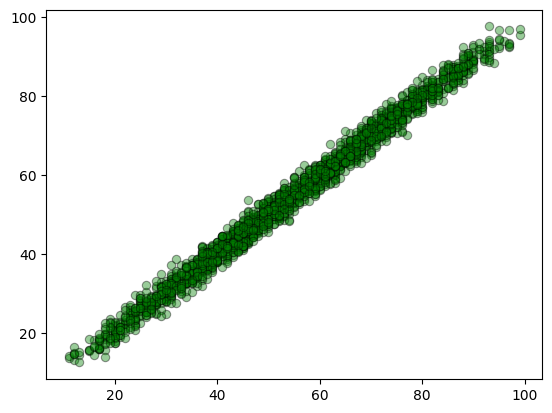

In [80]:
#NOTE : visualizatoin
plt.scatter(y_test,ŷ, linewidths=0.8, alpha=0.4, edgecolors='black', color='green')


Text(0.5, 1.0, 'Actual Vs Predicted')

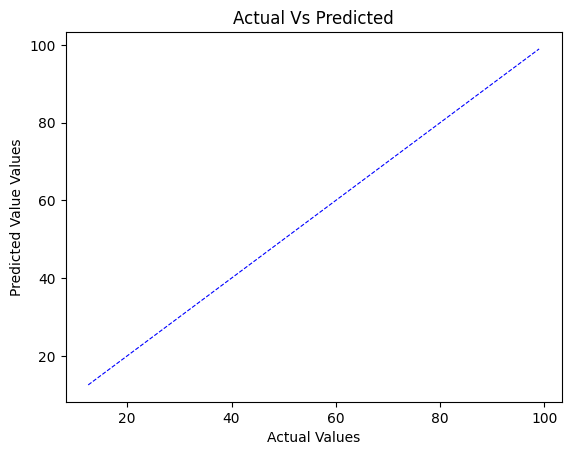

In [81]:
min_value = min(min(ŷ),max(y_test))
max_value = max(min(ŷ),max(y_test))
plt.plot([min_value, max_value], [min_value, max_value], 'b--', linewidth='0.8')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Value Values')
plt.title('Actual Vs Predicted')



/var/folders/jf/8ft3n5497pn97syqdww0k3gr0000gn/T/ipykernel_1258/2581869173.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b--" (-> color='b'). The keyword argument will take precedence.
  plt.plot([min_value, max_value], [min_value, max_value], 'b--', linewidth='2', color='black')


Text(0.5, 1.0, 'Actual Vs Predicted')

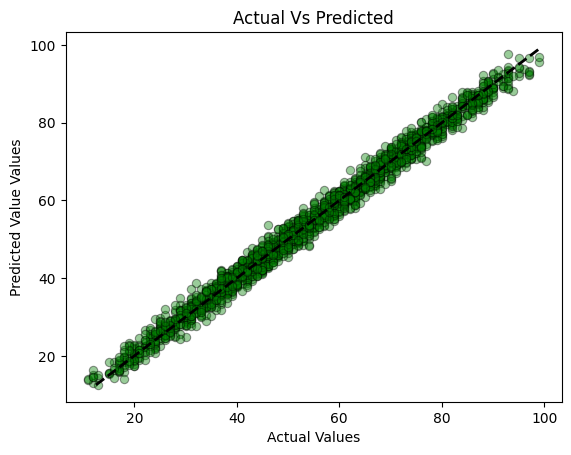

In [ ]:
plt.scatter(y_test,ŷ, linewidths=0.8, alpha=0.4, edgecolors='black', color='green')
min_value = min(min(ŷ),max(y_test))
max_value = max(min(ŷ),max(y_test))
plt.plot([min_value, max_value], [min_value, max_value], 'b--', linewidth='2', color='black')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Value Values')
plt.title('Actual Vs Predicted')
